# Exploratory Data Analysis (EDA) & Data Cleaning
**Objective:** Understand the distributions, check for missing values, and visualize the extreme class imbalance in our fraud dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Load raw data
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# 1. Basic Data Integrity Checks
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum().max()) # Should be 0
print("\nDuplicate Rows:", df.duplicated().sum())

# Drop duplicates for our analysis
df = df.drop_duplicates()

Dataset Shape: (284807, 31)

Missing Values:
 0

Duplicate Rows: 1081


/var/folders/qp/vybnj3gd0msg9ghj8pjsm_xc0000gq/T/ipykernel_80140/2534598616.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='Set2')


Fraudulent transactions make up only 0.167% of the dataset.


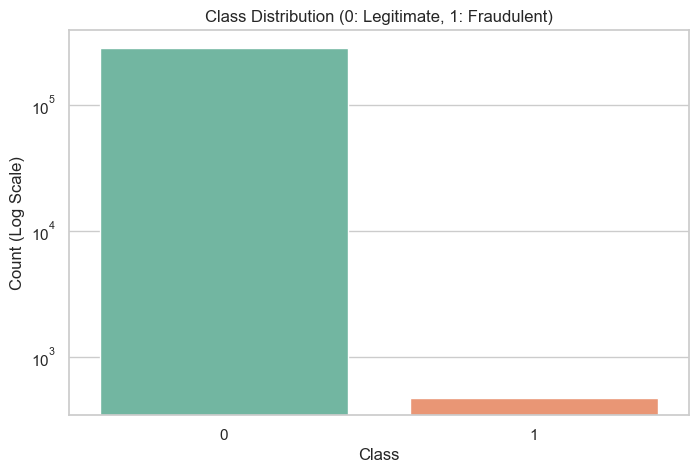

In [4]:
# 2. Visualize the Class Imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Class Distribution (0: Legitimate, 1: Fraudulent)')
plt.yscale('log') # Log scale is crucial here because of the extreme imbalance!
plt.ylabel('Count (Log Scale)')

# Calculate percentage
fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Fraudulent transactions make up only {fraud_pct:.3f}% of the dataset.")

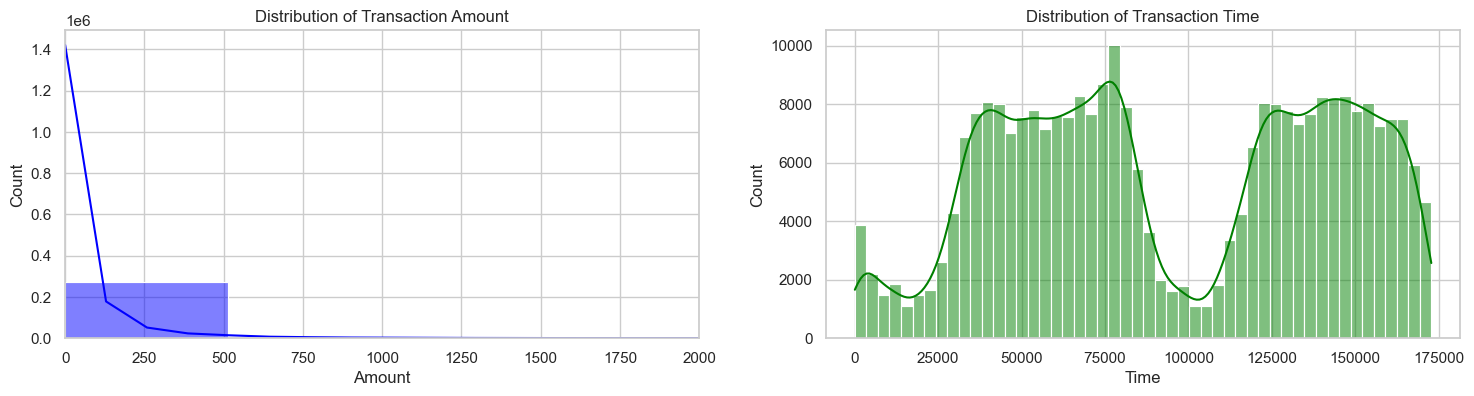

In [5]:
# 3. Feature Distributions: Time and Amount
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], bins=50, ax=ax[0], color='blue', kde=True)
ax[0].set_title('Distribution of Transaction Amount')
ax[0].set_xlim([0, 2000]) # Zooming in on the bulk of transactions

sns.histplot(df['Time'], bins=50, ax=ax[1], color='green', kde=True)
ax[1].set_title('Distribution of Transaction Time')

plt.show()

In [ ]:
# --- ADD THIS TO THE END OF YOUR 01_EDA_and_Cleaning.ipynb NOTEBOOK ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the original training labels and the new SMOTE labels
# (Make sure you ran data_prep.py first so these files exist!)
X_train = pd.read_csv('../data/processed/X_train_res.csv') # Just to get length if needed
y_train_res = pd.read_csv('../data/processed/y_train_res.csv').squeeze()

# To get the "Before SMOTE" data, we can just look at our original raw dataframe 'df'
# For the sake of the graph, we will split it quickly here
from sklearn.model_selection import train_test_split
X_temp = df.drop('Class', axis=1)
y_temp = df['Class']
_, _, y_train_original, _ = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)


# 2. Plot the Before and After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Before SMOTE (Using a log scale to see the tiny fraud bar)
sns.countplot(x=y_train_original, ax=axes[0], palette='Blues')
axes[0].set_title('Training Data BEFORE SMOTE\n(Severe Imbalance)')
axes[0].set_xlabel('Class (0: Legitimate, 1: Fraud)')
axes[0].set_ylabel('Number of Transactions (Log Scale)')
axes[0].set_yscale('log') 

# Plot 2: After SMOTE
sns.countplot(x=y_train_res, ax=axes[1], palette='Oranges')
axes[1].set_title('Training Data AFTER SMOTE\n(Perfectly Balanced)')
axes[1].set_xlabel('Class (0: Legitimate, 1: Fraud)')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()